# 🎵 Exploration préliminaire avec **pandas**

## Charger les données
On utilise `pandas.read_csv` qui charge directement le fichier dans un DataFrame.  
Fini les listes et les index numériques : chaque colonne a un **nom**.

Documentation pandas : https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

In [2]:
import pandas as pd


In [3]:
import os # au cas où problème accès fichier
os.getcwd()

'c:\\Users\\ANDRES\\Downloads'

In [4]:
data = pd.read_csv (r"C:\Users\ANDRES\Desktop\projet_spotify\data\spotify_alltime_top100_songs (2).csv")

## Sélectionner des parties des données

### Afficher les deux premières lignes. Que représentent-elles ?

In [5]:
data.head(2)

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100


### Afficher la seconde colonne de chacune de ces deux lignes

In [6]:
data.iloc[:2, 1]

0    Blinding Lights
1       Shape of You
Name: song_title, dtype: object

### Afficher le titre de la chanson classée 47ème

In [7]:
data.iloc[47, 1]

'goosebumps'

### Combien de chansons sont produites par le CANADA

**`query()`** exprime un filtre comme une chaîne de caractères lisible.  
C'est particulièrement pratique pour les conditions sur du texte ou des nombres.  
Doc : https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html

In [8]:
canada = data.query("artist_country == 'Canada'")
len(canada)

8

### Extraire l'information concernant l'année de sortie
Avec pandas, une colonne entière s'extrait en une ligne — pas besoin de boucle.

In [9]:
data['release_year']

0     2019
1     2017
2     2018
3     2018
4     2016
      ... 
95    2018
96    2020
97    2018
98    2020
99    2014
Name: release_year, Length: 100, dtype: int64

### Afficher les 15 premières et les 5 dernières valeurs

In [10]:
data.iloc[-5:]

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
95,96,Electricity,Silk City & Dua Lipa,1.92,EDM/Pop,143,2018,UK,False,0.76,0.88,0.72,0.00,Spotify All-Time Most Streamed Top 100
96,97,Blinding Lights (Remix),The Weeknd & Rosalía,1.44,Synth-Pop,171,2020,Canada/Spain,False,0.54,0.80,0.36,0.01,Spotify All-Time Most Streamed Top 100
97,98,Falling For You,Peachy feat. mxmtoon,1.56,Indie Pop,150,2018,USA,False,0.64,0.42,0.72,0.38,Spotify All-Time Most Streamed Top 100
98,99,Laugh Now Cry Later,Drake ft. Lil Durk,3.05,Hip-Hop,142,2020,Canada,True,0.82,0.62,0.55,0.02,Spotify All-Time Most Streamed Top 100
99,100,Shake It Off,Taylor Swift,1.60,Pop,160,2014,USA,False,0.65,0.80,0.94,0.06,Spotify All-Time Most Streamed Top 100


In [11]:
data.iloc[0:15]

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100
5,6,Stay,The Kid LAROI & Justin Bieber,3.87,Pop,170,2021,Australia,True,0.59,0.80,0.60,0.00,Spotify All-Time Most Streamed Top 100
6,7,Believer,Imagine Dragons,3.76,Alt Rock,125,2017,USA,False,0.33,0.86,0.45,0.07,Spotify All-Time Most Streamed Top 100
7,8,Rockstar,Post Malone ft. 21 Savage,3.72,Hip-Hop,159,2017,USA,True,0.55,0.52,0.13,0.08,Spotify All-Time Most Streamed Top 100
8,9,Dance Monkey,Tones and I,3.69,Pop,98,2019,Australia,False,0.83,0.63,0.73,0.14,Spotify All-Time Most Streamed Top 100
9,10,Happier,Marshmello & Bastille,3.65,EDM/Pop,100,2018,USA/UK,False,0.62,0.82,0.96,0.02,Spotify All-Time Most Streamed Top 100


### Quelle est la plus ancienne / la plus récente année de sortie ?

In [12]:
data['release_year'].max()

2024

In [13]:
data['release_year'].min()

1985

### Combien de chansons sont sorties en 2018 ?

In [14]:
data2 = data.query("release_year ==2018")
print(len(data2),"chansons sont sorties en 2018")


10 chansons sont sorties en 2018


### Combien de chansons ont été publiées année par année ?

💡 Astuce : `value_counts()` + `sort_index()`

In [15]:
year_per_year = data['release_year'].value_counts().sort_index()
print(year_per_year) # mais ne prend pas en compte les données manquantes

release_year
1985     1
1991     1
1994     1
1996     1
1998     1
2001     1
2002     1
2003     1
2006     1
2012     1
2013     5
2014     5
2015     2
2016     8
2017    10
2018    10
2019    13
2020    10
2021    10
2022     6
2023     4
2024     7
Name: count, dtype: int64


### Nombre moyen de chansons publiées chaque année

In [16]:
avg_songs = data['release_year'].value_counts().sort_index().mean()
print(avg_songs) # prends pas en compte les données manquantes ce qui fausse la moyenne

4.545454545454546


### Combien de pays différents sont recensés ?

💡 astuce: méthodes intéressantes:

- `.split()`, `.strip()`
- `.explode()`
- `.unique()`

In [17]:
nb_pays = data['artist_country'].explode().unique()
print("Il y a",len(nb_pays),"pays recensés")


Il y a 17 pays recensés


### Extraire tous les titres des chansons

In [18]:
data['song_title']

0             Blinding Lights
1                Shape of You
2           Someone You Loved
3                   Sunflower
4                   One Dance
               ...           
95                Electricity
96    Blinding Lights (Remix)
97            Falling For You
98        Laugh Now Cry Later
99               Shake It Off
Name: song_title, Length: 100, dtype: object

## Manipuler les structures de données

### Stocker conjointement l'année de sortie et le nom de l'artiste dans un tuple

In [19]:
year_and_name = data[['release_year', 'artist']].apply(tuple, axis=1)
print(year_and_name)

0                 (2019, The Weeknd)
1                 (2017, Ed Sheeran)
2              (2018, Lewis Capaldi)
3     (2018, Post Malone & Swae Lee)
4                      (2016, Drake)
                   ...              
95      (2018, Silk City & Dua Lipa)
96      (2020, The Weeknd & Rosalía)
97      (2018, Peachy feat. mxmtoon)
98        (2020, Drake ft. Lil Durk)
99              (2014, Taylor Swift)
Length: 100, dtype: object


### (Année de sortie, nombre de chansons) par ordre croissant

In [20]:
nb_chansons_annee = data['release_year'].value_counts().sort_index().reset_index()
print(nb_chansons_annee)
type(nb_chansons_annee)

    release_year  count
0           1985      1
1           1991      1
2           1994      1
3           1996      1
4           1998      1
5           2001      1
6           2002      1
7           2003      1
8           2006      1
9           2012      1
10          2013      5
11          2014      5
12          2015      2
13          2016      8
14          2017     10
15          2018     10
16          2019     13
17          2020     10
18          2021     10
19          2022      6
20          2023      4
21          2024      7


pandas.core.frame.DataFrame

Trier par nombre de chansons (ordre décroissant)

In [21]:
nb_chansons = data['artist'].value_counts()
print(nb_chansons) # j'ai pas compris cette question

artist
Harry Styles                   5
Ed Sheeran                     5
The Weeknd                     3
Taylor Swift                   3
Imagine Dragons                3
                              ..
Luis Fonsi ft. Daddy Yankee    1
The Neighbourhood              1
Mark Ronson ft. Bruno Mars     1
Billie Eilish & Khalid         1
Drake ft. Lil Durk             1
Name: count, Length: 80, dtype: int64


### Quel pays a le plus de chansons dans le top 100 ?

In [22]:
most_songs = data['artist_country'].value_counts().idxmax()
print("Le pays avec le plus de chansons dans le top 100 sont les",most_songs)


Le pays avec le plus de chansons dans le top 100 sont les USA


### Quelle est la chanson la plus streamée / la moins streamée ?

In [23]:
less_streamed = data.loc[data["total_streams_billions"].idxmin(), "song_title"]
print("La musique la moins streamée est",less_streamed)

La musique la moins streamée est Beautiful Things


In [24]:
most_streamed2 = data.loc[data["total_streams_billions"].idxmax(), "song_title"]
print("La musique la plus streamée est", most_streamed2)   

La musique la plus streamée est Blinding Lights


In [25]:
most_streamed1 = [(title, stream) for title, stream in zip(data['song_title'], data['total_streams_billions'])]
print(most_streamed1) #première technique que j'ai utilisé mais je n'y arrive pas


[('Blinding Lights', 5.26), ('Shape of You', 4.9), ('Someone You Loved', 4.05), ('Sunflower', 3.98), ('One Dance', 3.92), ('Stay', 3.87), ('Believer', 3.76), ('Rockstar', 3.72), ('Dance Monkey', 3.69), ('Happier', 3.65), ('Senorita', 3.62), ('Watermelon Sugar', 3.58), ('Perfect', 3.55), ('Levitating', 3.52), ('Heat Waves', 3.4), ('Bad Guy', 3.37), ('Drivers License', 3.34), ('Circles', 3.31), ('Memories', 3.28), ('Shallow', 3.25), ('As It Was', 3.22), ('Dynamite', 3.19), ('Flowers', 3.16), ('Counting Stars', 3.14), ('Lucid Dreams', 3.11), ('Closer', 3.08), ('Calm Down', 3.02), ('Anti-Hero', 2.99), ('Save Your Tears', 2.88), ('Die For You', 2.86), ('Lovely', 2.84), ('Uptown Funk', 2.53), ('Sweater Weather', 2.47), ('Cruel Summer', 2.72), ('Despacito', 2.15), ('Havana', 2.13), ('Easy On Me', 2.02), ('Lose Yourself', 1.95), ('Numb', 1.82), ('Smells Like Teen Spirit', 1.8), ('Espresso', 1.76), ('Radioactive', 1.74), ('Running Up That Hill', 1.52), ('Not Like Us', 1.5), ('good 4 u', 1.48), 

### Histogramme de la distribution des streams

Doc : https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

Axes(0.125,0.11;0.775x0.77)


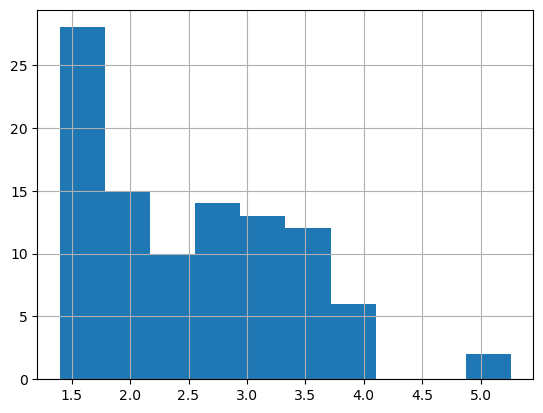

In [26]:
histogramme_streams = data["total_streams_billions"].hist()
print(histogramme_streams)

### Indice de "dansabilité" > 80 %

In [27]:
danceability_index = data["danceability"]>0.8
print(danceability_index)

0     False
1      True
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98     True
99    False
Name: danceability, Length: 100, dtype: bool


### Combien de chansons dépassent 2 milliards de streams ?

In [28]:
more_than_two_billions = data["total_streams_billions"]>=2.0
print(more_than_two_billions)


0      True
1      True
2      True
3      True
4      True
      ...  
95    False
96    False
97    False
98     True
99    False
Name: total_streams_billions, Length: 100, dtype: bool


### Créer et sauvegarder un fichier : chansons > 2 Mds streams ET dansabilité > 80 %

In [29]:
fichier_sauve = data.query("total_streams_billions > 2 and danceability > 0.8")
fichier_sauve.to_csv('chansons', index = False)

## Manipulation de dictionnaires et sets — Analyse des artistes

Ressources utiles :  
- Timer : https://ipython.readthedocs.io/en/stable/interactive/magics.html  
- Sets in Python : https://realpython.com/python-sets/  
- Dictionaries in Python : https://realpython.com/python-dicts/

### Identifier tous les artistes uniques (en séparant les collaborations)

In [30]:
artistes_uniques = data['artist'].str.split(' & ').explode().str.strip().unique()
print("Il y a",len(artistes_uniques),"artistes uniques")


Il y a 88 artistes uniques


### Compter le nombre de chansons par artiste

💡 Astuce: la méthode `value_counts()` peut être utile

In [44]:
nb_songs_per_artist = data['artist'].value_counts().reset_index()
print(nb_songs_per_artist)

                         artist  count
0                  Harry Styles      5
1                    Ed Sheeran      5
2                    The Weeknd      3
3                  Taylor Swift      3
4               Imagine Dragons      3
..                          ...    ...
75  Luis Fonsi ft. Daddy Yankee      1
76            The Neighbourhood      1
77   Mark Ronson ft. Bruno Mars      1
78       Billie Eilish & Khalid      1
79           Drake ft. Lil Durk      1

[80 rows x 2 columns]


### Artiste le plus prolifique

💡 Astuce: la méthode `idxmax()` peut être utile

In [ ]:
best_artiste = data.loc[data["total_streams_billions"].idxmax(), "artist"]
print("L'artiste le plus prolifique est", best_artiste)

L'artiste le plus prolifique est The Weeknd


### Proportion de collaborations

In [ ]:
prop_collab = data["artist"].str.contains("&").mean()
print(prop_collab)

0.15


# PARTIE OPTIONNELLE

## Analyse du BPM

In [35]:
data["bpm"].reset_index()

,index,bpm
0,0,171
1,1,96
2,2,77
3,3,93
4,4,100
...,...,...
95,95,143
96,96,171
97,97,150
98,98,142


### Chansons avec BPM > 140

In [ ]:
data["bpm"].reset_index()>140

,bpm,count
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False
...,...,...
58,False,False
59,True,False
60,True,False
61,False,False


### Tuples (track_name, bpm) triés par BPM décroissant

### Visualisation : distribution des BPM

### Histogramme du nombre de chansons par année (depuis 2015)

### Chansons à la fois très énergétiques (> 0.8) ET très dansables (> 0.7)

### Tuples (track_name, danceability, energy, valence) triés par danceability